<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/06.Karpathy Char RNN-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd {repository_name}

<span style="font-size:3em; line-height:36px"><strong>RNNs and LSTMs for Character-Level Language Models
</strong></span>
- 이 자료는 Andrej Karpathy의 블로그 글 [The Unreasonable Effectiveness of Recurrent eural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)를 PyTorch로 구현한 것입니다.


## References
- http://karpathy.github.io/2015/05/21/rnn-effectiveness/
- http://colah.github.io/posts/2015-08-Understanding-LSTMs/
- https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21

## Karpathy's character level language model
<img src="http://karpathy.github.io/assets/rnn/charseq.jpeg" width="400" height="400">

In [6]:
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import urllib.request

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data Preprocessing

In [7]:

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
filename = 'shakespeare_data.txt'
urllib.request.urlretrieve(url, filename)

data_file = open(filename, 'r')
raw_data = data_file.read()
data_file.close()

print(raw_data[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



- Vocabulary의 각 char를 index로 매핑
- Character를 one-hot encoding

In [8]:
data_length = len(raw_data)
vocab = sorted(list(set(raw_data)))
vocab_size = len(vocab)

char_to_index = { char:index for (index,char) in enumerate(vocab) }
index_to_char = { index:char for (index,char) in enumerate(vocab) }

print(f"데이터셋의 총 char 수 = {data_length}")
print()
print(f"Vocabulary = {vocab}")
print()
print(f"Vocabulary 크기 = {vocab_size}")
print()
print(f"char_to_index = {char_to_index}")
print()
print(f"index_to_char = {index_to_char}")

데이터셋의 총 char 수 = 1115394

Vocabulary 내용 ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Vocabulary 크기 = 65

char_to_index {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}

index_to_char {0: '\

In [9]:
def create_one_hot(ind, length):
    """인덱스를 one-hot 벡터로 변환"""
    vec = np.zeros(length)
    vec[ind] = 1
    return vec

create_one_hot(2, 12)

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [10]:
def chunk_data(raw_data, seq_len):
    """원시데이터를 같은 크기의 청크들로 분할"""
    chunks = []

    for i in range(len(raw_data) // seq_len):
        start = i * seq_len
        end = start + seq_len
        chunk = raw_data[start:end]
        # chunk += (10 - len(chunk))*'\n'
        chunks.append(chunk)
        
    return chunks

chunked_data = chunk_data(raw_data[:104], 12)
chunked_data

['First Citize',
 'n:\nBefore we',
 ' proceed any',
 ' further, he',
 'ar me speak.',
 '\n\nAll:\nSpeak',
 ', speak.\n\nFi',
 'rst Citizen:']

In [11]:
def convert_dataset(dataset, char_to_index, vocab_size):
    """character sequence 데이터셋을 인덱스와 one-hot 데이터로 변환"""
    ind_dataset = np.zeros((len(dataset), len(dataset[0])), dtype=np.int32)
    one_hot_dataset = np.zeros((len(dataset), len(dataset[0]), vocab_size), dtype=np.float32)

    for i, seq in enumerate(dataset):
        ind_seq = [char_to_index[c] for c in seq]
        one_hot_seq = [create_one_hot(ind, vocab_size) for ind in ind_seq]
        
        ind_dataset[i, :] = np.array(ind_seq, dtype=np.float32)
        one_hot_dataset[i, :, :] = np.asarray(one_hot_seq, dtype=np.float32)

    return ind_dataset, one_hot_dataset
ind_dataset, one_hot_dataset = convert_dataset(chunked_data, char_to_index, vocab_size)
print(ind_dataset.shape)
print(one_hot_dataset.shape)

(8, 12)
(8, 12, 65)


one_hot_dataset = batch_size(8) x seq_length(12) x vector_size(65)

In [12]:
class ShakespeareDataset(Dataset):
    def __init__(self, inds, one_hot):
        self.inds = inds
        self.one_hot = one_hot

    def __len__(self):
        return self.one_hot.size(0)

    def __getitem__(self, idx):
        # 각 char의 target sequencer가 바로 다음 char의 seq가 되도록 offset시킴
        input_onehot = self.one_hot[idx, :-1, :]
        target_ind = self.inds[idx, 1:]

        return input_onehot, target_ind

In [13]:
seq_length = 25

data_chunks = chunk_data(raw_data, seq_length)
train_ind, train_oh = convert_dataset(data_chunks, char_to_index, vocab_size)
train_ind.shape, train_oh.shape

((44615, 25), (44615, 25, 65))

In [14]:
# Send data to GPU
train_ind_tt = torch.Tensor(train_ind).long().to(device)
train_oh_tt = torch.Tensor(train_oh).float().to(device)

train_set = ShakespeareDataset(train_ind_tt, train_oh_tt)

# Recurrent Neural Networks

$$ 
\begin{align} a_t &= W_{xh} x_t + W_{hh} h_{t-1} + b_{h}\\
 h_t &= \text{tanh}(a_t) \\
 y_t &= \text{softmax}(W_{hy} h_t + b_{y}) 
 \end{align} 
$$
 
 
You may find the following resources helpful for understanding how RNNs and LSTMs work:

* [The Unreasonable Effectiveness of RNNs (Andrej Karpathy)](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* [Recurrent Neural Networks Tutorial (Wild ML)](http://www.wildml.com/2015/09/recurrent-neural-networks-tutorial-part-1-introduction-to-rnns/)
* [Understanding LSTM Networks (Chris Olah)](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)
 
 
## Implementation

In [39]:
class VanillaCell(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size = hidden_size
        
        # Network Parameters
        # Input -> hidden (before activation)
        self.Wxh = nn.Parameter(torch.randn((input_size, hidden_size)))
        self.Whh = nn.Parameter(torch.randn((hidden_size, hidden_size)))
        self.bh = nn.Parameter(torch.zeros((hidden_size)))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((hidden_size, output_size)))
        self.by = nn.Parameter(torch.zeros((output_size))) 
        
        # Activations
        self.tanh = nn.Tanh()
        
        # Output probability
        self.softmax = nn.LogSoftmax(dim=1)
        """
        def init(self):
        # Initialize hidden state to zero
        self.h = torch.zeros((self.hidden_size))
        """    

    def forward(self, X, hidden):
        hidden = self.tanh((X @ self.Wxh) + (hidden @ self.Whh + self.bh))
        y_output = hidden @ self.Why + self.by
        return y_output, hidden

In [40]:
class CharRNN(nn.Module):
    cells = {
        "LSTM"       : LSTMCell,
        "GRU"        : GRUCell,
        "vanillaRNN" : VanillaCell
    }
    
    def __init__(self, input_size, hidden_size, output_size, cell_type='vanillaRNN'):
        super().__init__()

        self.hidden_size = hidden_size
        self.output_size = output_size
        self.cell_type = cell_type
        print(f"Creating RNN with cell: {cell_type}")
        self.RNNcell = CharRNN.cells[cell_type](input_size, hidden_size, output_size)
        
        self._init_weights()
    
    def _init_weights(self):
        for param in self.RNNcell.parameters():
            param.requires_grad_(True)
            print("Initializing parameters")
            print(f"- parameter type: {type(param)}")
            print(f"- parameter size: {param.size()}")
            if param.data.ndimension() >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.zeros_(param.data)
                
    def init_hidden(self, batch_size, device):
        """Initialize RNN hidden state.
        
        Some people advocate for using random noise instead of zeros, or 
        training for the initial state. Personally, I don't know if it matters!
        """
        return torch.zeros(batch_size, self.hidden_size, device=device)
    
    def forward(self, X):
        """입력 sequence X에 대한 forward pass 수행.
        
        X의 shape = (B x L x D):
            B: batch size
            L: sequence length
            D: vocab_size
        """
        batch_size, seq_len, n_feat = X.size()
        
        # RNN cell output 저장
        output_arr = torch.zeros((batch_size, seq_len, self.output_size))
        hidden_arr = torch.zeros((batch_size, seq_len, self.hidden_size))
        
        # Send to GPU
        output_arr = output_arr.float().to(X.device)
        hidden_arr = hidden_arr.float().to(X.device)

        hidden = self.init_hidden(batch_size, X.device)

        for i in range(seq_len):
            # 각 순회마다 현재 위치 입력에 대해 RNN 계산
            output, hidden = self.RNNcell(X[:, i, :], hidden)

            output_arr[:, i, :] = output
            hidden_arr[:, i, :] = hidden

        return output_arr, hidden_arr

## Training

In [41]:
def generate_seq(model, init_char_one_hot, length):
    """Generate sequence
      1. RNN에서 다음 char의 분포를 구한다
      2. 이 분포를 사용하여 다음 char를 샘플링(예측)한다
      3. 샘플링된 char를 RNN에 입력으로 준다
      4. 위 절차를 반복한다
    """
    curr_char = init_char_one_hot  # 시작 char의 one-hot vector
    output = index_to_char[torch.argmax(curr_char.squeeze()).item()]

    for i in range(length):
        out, _ = model(curr_char)

        # 출력이 확률분포이므로, 이것으로부터 샘플을 생성할 수 있다
        print(out)
        p = np.exp(out[:, -1, :].cpu().detach().numpy())
        out_ind = np.random.choice(range(vocab_size), p=p.ravel())
        
        out_char = index_to_char[out_ind]
        
        output += out_char
        
        # 예측된 char는 다음 시간스텝의 입력으로 사용된다
        curr_char = create_one_hot(out_ind, vocab_size)
        curr_char = torch.Tensor(curr_char).float().to(device).view(1, 1, -1)

    return output

In [42]:
def train_loop(model, optimizer, train_loader, n_epochs, test_char=None):
    for epoch in range(n_epochs):
        avg_loss = []
        for input_seq, target_ind in train_loader:
            optimizer.zero_grad()

            output, _ = model(input_seq)
            loss = nn.NLLLoss()(output.transpose(1, 2), target_ind)

            loss.backward()
            
            # =================================================================
            # This is how to do gradient clipping in PyTorch
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            # =================================================================
            
            optimizer.step()
            avg_loss.append(loss.item())

        print('Epoch {} : Avg Train Loss {}'.format(epoch, np.mean(avg_loss)))

        # Generate sequence
        if test_char is not None:
            gen_seq = generate_seq(model, test_char, 100)
            print("Generated Sequence:\n {}".format(gen_seq))

In [43]:
HIDDEN_SIZE = 100
N_EPOCH = 100
LR = 0.01
BATCH_SIZE = 64
SAMP_CHAR = 'a'

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

model = CharRNN(vocab_size, HIDDEN_SIZE, vocab_size).to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)

test_char = create_one_hot(char_to_index[SAMP_CHAR], vocab_size)
test_char_tt = torch.Tensor(test_char).view(1, 1, -1).float().to(device)

train_loop(model, optim, train_loader, N_EPOCH, test_char_tt)

Creating RNN with cell: vanillaRNN
Initializing parameters
- parameter type: <class 'torch.nn.parameter.Parameter'>
- parameter size: torch.Size([65, 100])
Initializing parameters
- parameter type: <class 'torch.nn.parameter.Parameter'>
- parameter size: torch.Size([100, 100])
Initializing parameters
- parameter type: <class 'torch.nn.parameter.Parameter'>
- parameter size: torch.Size([100])
Initializing parameters
- parameter type: <class 'torch.nn.parameter.Parameter'>
- parameter size: torch.Size([100, 65])
Initializing parameters
- parameter type: <class 'torch.nn.parameter.Parameter'>
- parameter size: torch.Size([65])
Epoch 0 : Avg Train Loss -351.99959725823203


C:\Users\a\AppData\Local\Temp/ipykernel_10300/1150853249.py:15: RuntimeWarning: overflow encountered in exp
  p = np.exp(out[:, -1, :].cpu().detach().numpy())


ValueError: probabilities contain NaN

# Train

Epoch 101/5000 -- Loss: 0.6056 -- Network out: Hello, RNN!
Ending early. Converged in 100 epochs.


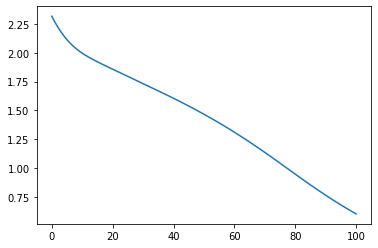

In [11]:
N_EPOCHS = 5000
LR = 0.005
end_early = False
seq_i = ""

net.train() # Ensure net in training mode
for epoch_i in range(N_EPOCHS):
    # Zero out gradients
    optimizer.zero_grad()
    
    # Get net output, calculate loss, and generate gradients
    output = net(data.X)
    loss = criterion(output, data.y)
    loss.backward() # Generate gradients via autodiff
    
    # Step
    # -----------------------------------
    # Clip params
    for param in net.parameters():
        if param.grad is None:
            continue
        grad_val = torch.clamp(param.grad, -5, 5)
    optimizer.step()
    # -----------------------------------
    
    # Track loss
    losses.append(loss.item())
    
    # Qualitative Eval
    if epoch_i % 10 == 0:
        seq_i = net.generate(data, data.string[0], num_steps=len(data.string))
        
        if seq_i == data.string:
            end_early = True
            
    # Stdout
    # --------------------------------
    stdout_str = f'\rEpoch {epoch_i+1}/{N_EPOCHS} -- Loss: {losses[-1]:0.4f} -- Network out: {seq_i}'
    sys.stdout.write(stdout_str)
    sys.stdout.flush()
    # --------------------------------
    
    if end_early:
        print(f"\nEnding early. Converged in {epoch_i} epochs.")
        break
    
plt.plot(losses)

# Generate Text

In [12]:
init_char = data.string[0]
net.generate(data, init_char, num_steps=len(data.string))

'Hello, RNN!'

In [18]:
class LSTMCell(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        
        # Network Parameters
        # Potential Input
        self.Wxh = nn.Parameter(torch.randn((vocab_size, hidden_size)))
        self.Whh = nn.Parameter(torch.randn((hidden_size, hidden_size)))
        self.bh = nn.Parameter(torch.zeros((hidden_size)))
        
        # Input gate parameters
        self.Wxh_i = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_i = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_i = nn.Parameter(torch.randn_like(self.bh))
        
        # Forget gate parameters
        self.Wxh_f = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_f = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_f = nn.Parameter(torch.randn_like(self.bh))
        
        # Output gate parameters
        self.Wxh_o = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_o = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_o = nn.Parameter(torch.randn_like(self.bh))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((hidden_size, vocab_size)))
        self.by = nn.Parameter(torch.zeros((vocab_size))) 
        
        # Activations
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    
    def init(self):
        self.h = torch.zeros((self.hidden_size))  # Hidden state
        self.c = torch.zeros((self.hidden_size))  # Cell state
        
    def forward(self, x):
        potential_input = self.tanh((x @ self.Wxh) + (self.h @ self.Whh + self.bh))
        
        # Gate updates
        input_gate = self.sigmoid((x @ self.Wxh_i) + (self.h @ self.Whh_i + self.bh_i))
        forget_gate = self.sigmoid((x @ self.Wxh_f) + (self.h @ self.Whh_f + self.bh_f))
        output_gate = self.sigmoid((x @ self.Wxh_o) + (self.h @ self.Whh_o + self.bh_o))
        
        # Update c and h
        self.c = self.c * forget_gate + potential_input * input_gate
        self.h = output_gate * self.tanh(self.c)
        
        y_output = self.h @ self.Why + self.by
        
        return y_output

In [19]:
class GRUCell(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        
        # Network Parameters
        # Potential Input
        self.Wxh = nn.Parameter(torch.randn((vocab_size, hidden_size)))
        self.Whh = nn.Parameter(torch.randn((hidden_size, hidden_size)))
        self.bh = nn.Parameter(torch.zeros((hidden_size)))
        
        # Update gate parameters
        self.Wxh_u = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_u = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_u = nn.Parameter(torch.randn_like(self.bh))
        
        # Reset gate parameters
        self.Wxh_r = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_r = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_r = nn.Parameter(torch.randn_like(self.bh))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((hidden_size, vocab_size)))
        self.by = nn.Parameter(torch.zeros((vocab_size))) 
        
        # Activations
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    
    def init(self):
        self.h = torch.zeros((self.hidden_size))  # Hidden state
        
    def forward(self, x):
        
        # Gate updates
        update_gate = self.sigmoid((x @ self.Wxh_u) + (self.h @ self.Whh_u + self.bh_u))
        reset_gate = self.sigmoid((x @ self.Wxh_r) + (self.h @ self.Whh_r + self.bh_r))
        
        potential_input = self.tanh((x @ self.Wxh) + (reset_gate @ self.Whh + self.bh))
        
        self.h = self.h * (1-update_gate) + (potential_input * update_gate)
        y_output = self.h @ self.Why + self.by
        
        return y_output